    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 1: Implement a program which, given (a) a query label, l (b) a user selected feature space, and (c) 
    positive integer k, identifies and visualizes the most relevant k images for the given label l, along with 
    their scores, under the selected feature space.

In [1]:
LABEL = input("Provide a valid label / label ID present in the Caltech101 dataset.")

FEATURE_SPACE = input("Provide a feature space [color, hog, avgpool, layer3, fc, resnet_output].")

K = int(input("Enter K, the number of similar images K to find for the selected feature space."))

In [2]:
# Find the k most similar images for a given query label for the given feature space.

from utils.query_input_processor import check_label_is_valid

LABEL = check_label_is_valid(LABEL)

Input label:  0
Files already downloaded and verified
Output label: Faces 




In [3]:
# Load feature space and representative label vectors for that feature space.

from utils.database_utils import retrieve

feature_vectors = retrieve(f'{FEATURE_SPACE}.pt')
rep_label_vectors = retrieve(f'rep_label_{FEATURE_SPACE}.pt')

Files already downloaded and verified

K = 10 most similar images by fc feature space using distance: cosine
1. 	Image ID:  32 		Distance:  0.06042683124542236


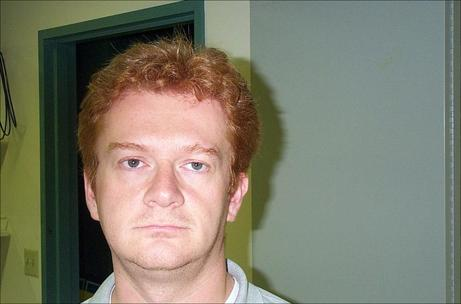

2. 	Image ID:  144 		Distance:  0.06847953796386719


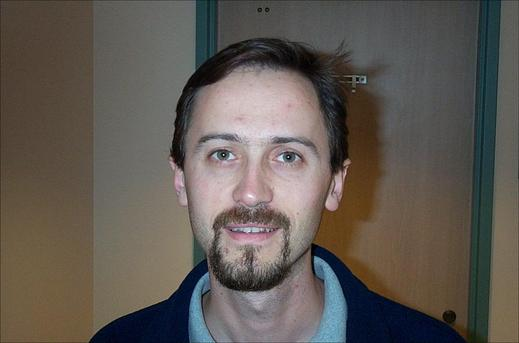

3. 	Image ID:  234 		Distance:  0.06924301385879517


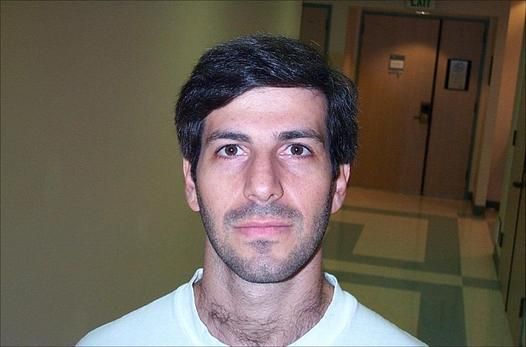

4. 	Image ID:  2 		Distance:  0.07103288173675537


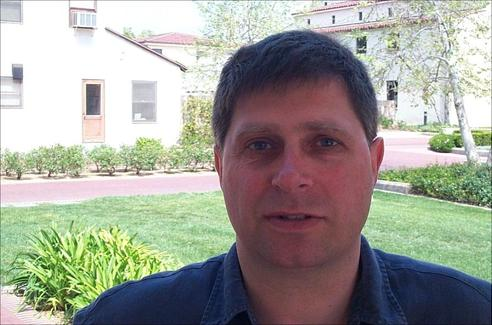

5. 	Image ID:  190 		Distance:  0.07286202907562256


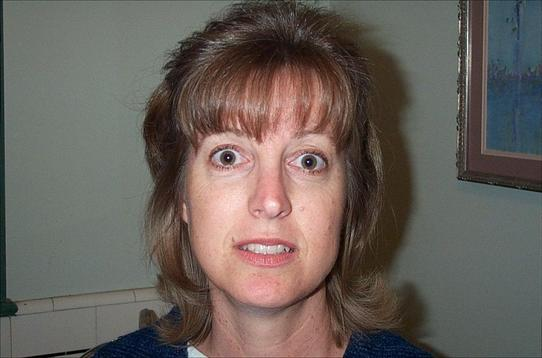

6. 	Image ID:  252 		Distance:  0.08075147867202759


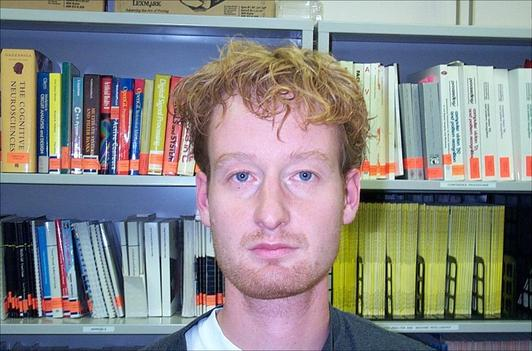

7. 	Image ID:  36 		Distance:  0.08434164524078369


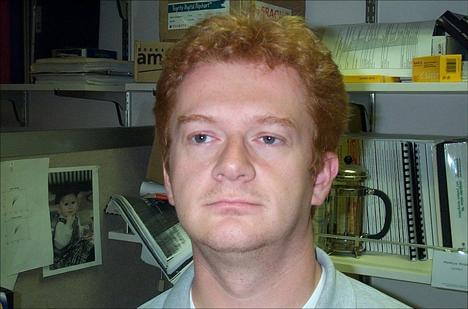

8. 	Image ID:  62 		Distance:  0.08472442626953125


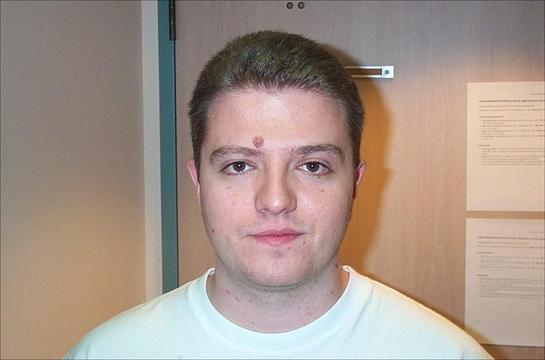

9. 	Image ID:  230 		Distance:  0.08484995365142822


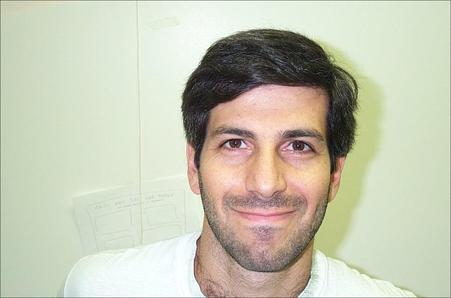

10. 	Image ID:  612 		Distance:  0.08730483055114746


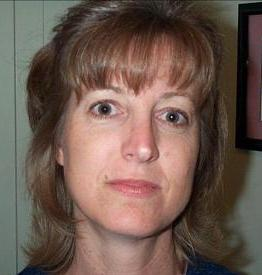

In [4]:
from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

from utils.distance_utils import get_distance_fn, top_k_min_distance_ranker
top_k = top_k_min_distance_ranker(K, rep_label_vectors[LABEL], feature_vectors, get_distance_fn(FEATURE_SPACE))

print("\nK =", K, "most similar images by", FEATURE_SPACE, "feature space using distance:", get_distance_fn(FEATURE_SPACE).__name__)

for i in range(len(top_k)):

    distance, image_id, label = top_k[i]

    print(str(i + 1) + ".", "\tImage ID: ", image_id, "\t\tDistance: ", distance)
    display(dataset[image_id][0])